# 2 — Pricing analysis

Two questions:

1. **Descriptive** — where does revenue come from, and how do customers split?
2. **Causal-ish** — which products are price-sensitive, and what would a small
   price move do?

The estimation code lives in `retail_pricing.elasticity` and
`retail_pricing.optimize`; this notebook is the narrative around it.

**Read the headline number with the caveats in `docs/findings.md`.** The short
version: prices here were set by the retailer, not randomised, so these are
associations, not experiments.

In [1]:
import pandas as pd

from retail_pricing import elasticity as el
from retail_pricing import plots
from retail_pricing.db import read_sql
from retail_pricing.optimize import portfolio_impact, recommend_price_changes

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 50)

## Trading pattern

A Christmas-gifting business: Q4 is roughly double the rest of the year. This
seasonality is why the demand model carries a market-wide control — without it,
products that are both pricier and busier in Q4 would look price-*insensitive*
purely from the season.

,week_start,revenue,units,invoices,customers,products_sold,revenue_per_invoice
96,2011-10-17,264358.21,152267,446,364,2210,592.73
97,2011-10-24,242683.19,149053,519,419,2190,467.60
98,2011-10-31,292747.79,158183,527,441,2330,555.50
99,2011-11-07,357169.72,181894,634,514,2335,563.36
100,2011-11-14,373178.36,184889,687,569,2414,543.20
101,2011-11-21,302392.22,154803,616,492,2388,490.90
102,2011-11-28,309381.73,156350,663,514,2296,466.64
103,2011-12-05,483725.13,244714,509,415,2317,950.34


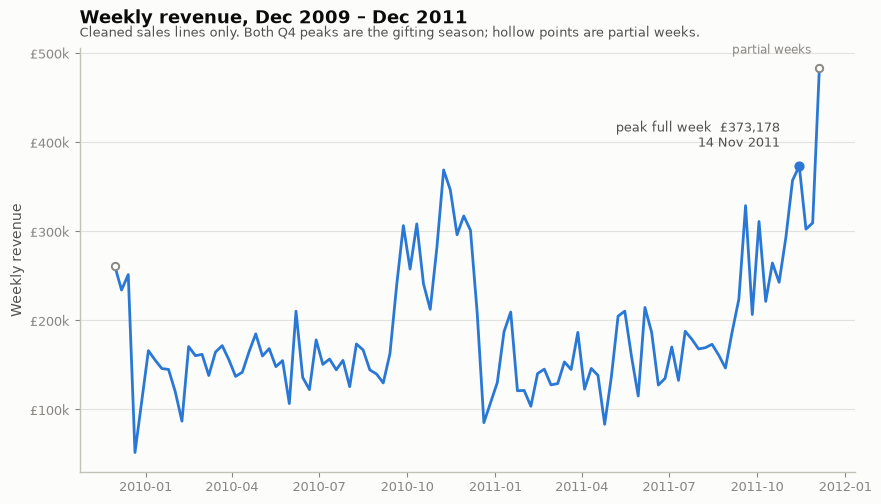

In [2]:
weekly = read_sql("SELECT * FROM marts.weekly_revenue ORDER BY week_start")
plots.plot_weekly_revenue(weekly);
weekly.tail(8)

## Where revenue concentrates

In [3]:
read_sql('''
    SELECT country,
           round(sum(line_revenue)::numeric, 0) AS revenue,
           count(DISTINCT invoice)              AS invoices,
           round(100.0 * sum(line_revenue) / sum(sum(line_revenue)) OVER (), 1) AS pct
    FROM staging.transactions
    GROUP BY country
    ORDER BY revenue DESC
    LIMIT 10
''')

,country,revenue,invoices,pct
0,United Kingdom,16800468.0,36184,85.5
1,EIRE,623414.0,581,3.2
2,Netherlands,549773.0,216,2.8
3,Germany,383289.0,753,2.0
4,France,311090.0,598,1.6
5,Australia,167800.0,89,0.9
6,Spain,97767.0,144,0.5
7,Switzerland,94025.0,85,0.5
8,Sweden,86319.0,99,0.4
9,Denmark,67423.0,42,0.3


## Customer segmentation (RFM)

Scored 1–5 on recency, frequency and monetary value. Recency is measured from
the last day in the dataset, not today — the data ends in December 2011.

In [4]:
rfm = read_sql("SELECT * FROM marts.customer_rfm")
segment = (
    rfm.assign(segment=lambda d: d.r_score.astype(str) + d.f_score.astype(str) + d.m_score.astype(str))
       .groupby(["r_score", "f_score"], as_index=False)
       .agg(customers=("customer_id", "count"), revenue=("monetary", "sum"))
)
segment.pivot(index="r_score", columns="f_score", values="revenue").round(0)

f_score,1,2,3,4,5
r_score,,,,,
1,122668.0,241818.0,176321.0,174311.0,86141.0
2,70893.0,181590.0,388480.0,344995.0,434574.0
3,47983.0,154381.0,328608.0,651842.0,1044125.0
4,29442.0,126901.0,246362.0,676317.0,2315819.0
5,13984.0,227341.0,203129.0,514710.0,8265297.0


## The price measure matters more than the model

`avg_price` is revenue ÷ units. Using it as the regressor puts quantity in the
denominator of the predictor and the numerator of the outcome, so noise in
units alone drags the slope negative — *division bias*.

Re-estimating under three price definitions shows the size of the artefact: the
median elasticity moves from −2.39 to −1.62 once the price measure no longer
contains quantity. The two quantity-independent measures agree with each other,
which is the reassuring part.

In [5]:
panel = el.load_panel()
comparison = el.compare_price_measures(panel)
comparison

,price_measure,products_fitted,median_elasticity,mean_elasticity,pct_elastic_below_-1,pct_wrong_signed
0,avg_price,2388,-2.387,-2.677,90.5,1.9
1,median_line_price,1885,-1.620,-1.711,81.0,1.9
2,modal_line_price,1110,-1.608,-1.662,82.0,1.4


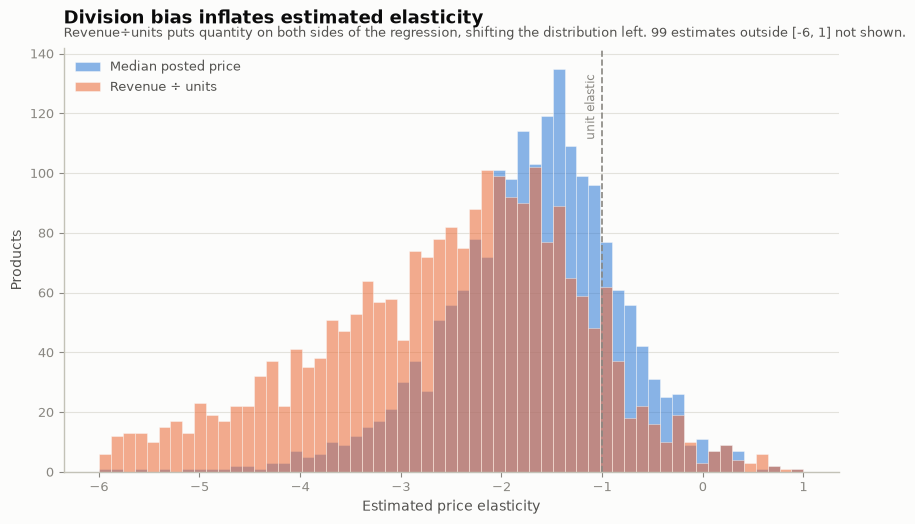

In [6]:
long = pd.concat([
    el.estimate_elasticities(panel, price_col=c).assign(measure=c)[["measure", "elasticity"]]
    for c in ("median_line_price", "avg_price")
])
plots.plot_division_bias(long);

## Estimating elasticity

For each product with enough price variation:

$$\log(\text{units}_{it}) = \alpha + \beta \log(\text{price}_{it}) + \gamma \log(\text{market units}_{it}) + \varepsilon_{it}$$

with Newey-West standard errors, and Benjamini-Hochberg FDR correction across
products because we are running ~1,900 regressions and some will look
significant by chance.

In [7]:
results = el.estimate_elasticities(panel)
el.summarise(results)

,metric,value
0,products fitted,1885.000
1,significant after FDR,1547.000
2,wrong-signed (positive) elasticity,36.000
3,significant AND positive (endogeneity flag),1.000
4,"defensible (significant, negative)",1546.000
5,of which elastic (b < -1),1422.000
6,of which inelastic (-1 <= b < 0),124.000
7,median elasticity (defensible),-1.787
8,revenue covered by defensible set,8310676.880


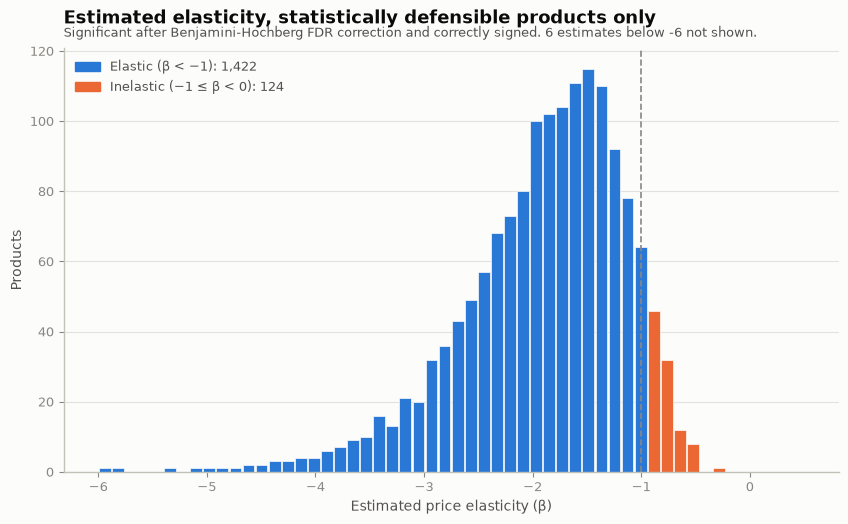

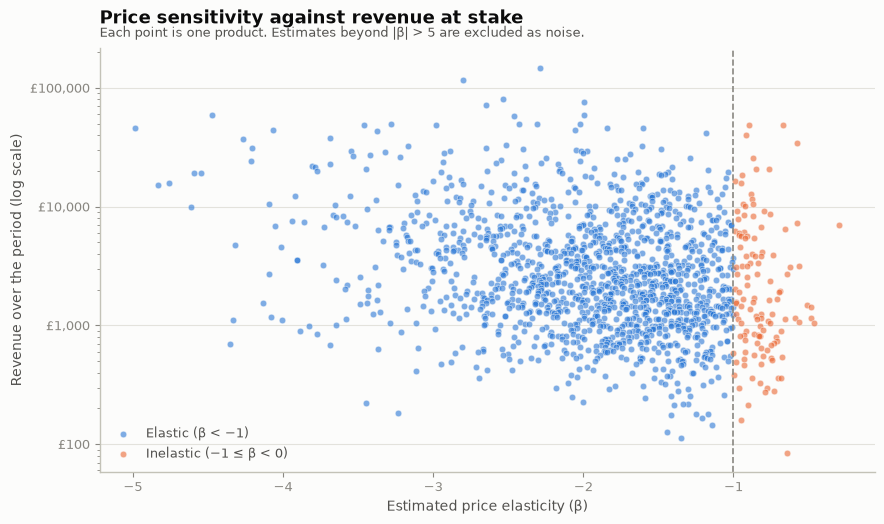

In [8]:
plots.plot_elasticity_distribution(results);
plots.plot_elasticity_vs_revenue(results);

## From elasticity to a recommendation

There is deliberately **no "optimal price" column**. Under constant elasticity,
revenue is monotonic in price — there is no interior maximum to solve for. So
the recommendation is a *bounded* move (±10%, and never outside the price range
the product has actually traded at), with the projected revenue range derived
from each elasticity's confidence interval.

In [9]:
recs = recommend_price_changes(results)
portfolio_impact(recs)

,segment,products,current_revenue,projected_delta,delta_low,delta_high,pct_of_segment_revenue
0,"price increases (inelastic, margin-safe)",11,25714.92,1291.92,429.07,2184.26,5.02
1,"price decreases (elastic, needs margin check)",867,5275062.41,620754.15,237607.91,1054463.33,11.77
2,all robust recommendations,878,5300777.33,622046.07,238036.98,1056647.59,11.73


### The asymmetry that matters

Price *increases* on inelastic products raise revenue and unit margin together
— they are safe without cost data. Price *cuts* on elastic products raise
revenue but may destroy profit, and this dataset has no cost of goods, so that
cannot be checked here.

Almost all of the projected uplift sits in the second, unverifiable category.
That is the honest headline.

In [10]:
safe = recs[(recs.direction == "increase") & recs.ci_agrees_on_sign]
safe[["stock_code", "elasticity", "current_price", "recommended_price",
      "total_revenue", "projected_revenue_delta",
      "revenue_delta_low", "revenue_delta_high"]].head(15)

,stock_code,elasticity,current_price,recommended_price,total_revenue,projected_revenue_delta,revenue_delta_low,revenue_delta_high
290,21700,-0.294759,0.85,0.94,7028.51,488.67,291.80,690.84
444,21876,-0.578939,1.25,1.38,7351.25,301.02,1.93,612.27
678,79164,-0.565542,1.65,1.82,3196.01,135.12,42.23,230.67
889,35965,-0.482327,2.95,3.25,1423.63,72.00,28.15,117.18
897,22915,-0.507657,0.42,0.46,1474.52,70.84,21.83,121.46
952,84313B,-0.481399,4.25,4.68,1164.04,58.98,11.02,108.90
977,37327,-0.464652,0.68,0.75,1051.69,55.05,16.44,95.06
1020,37475,-0.590190,9.95,10.94,1160.56,46.23,9.09,84.55
1023,20615,-0.564745,2.10,2.31,1077.81,45.65,4.75,88.10
1202,46118,-0.742673,2.49,2.74,513.58,12.75,1.71,24.03
